In [1]:
import pandas as pd
import numpy as np

Dataset Overview

In [2]:
df=pd.read_csv("Unemployment_Rate_upto_11_2020.csv")
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


The dataset contains information about unemployment rates across different regions over time. It includes features such as date, region, estimated unemployment rate, estimated employed,labour participation and geographical details.

In [3]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')

In [4]:
df.info

<bound method DataFrame.info of              Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0    Andhra Pradesh   31-01-2020          M                              5.48   
1    Andhra Pradesh   29-02-2020          M                              5.83   
2    Andhra Pradesh   31-03-2020          M                              5.79   
3    Andhra Pradesh   30-04-2020          M                             20.51   
4    Andhra Pradesh   31-05-2020          M                             17.43   
..              ...          ...        ...                               ...   
262     West Bengal   30-06-2020          M                              7.29   
263     West Bengal   31-07-2020          M                              6.83   
264     West Bengal   31-08-2020          M                             14.87   
265     West Bengal   30-09-2020          M                              9.35   
266     West Bengal   31-10-2020          M                              9.98

In [5]:
df.describe

<bound method NDFrame.describe of              Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0    Andhra Pradesh   31-01-2020          M                              5.48   
1    Andhra Pradesh   29-02-2020          M                              5.83   
2    Andhra Pradesh   31-03-2020          M                              5.79   
3    Andhra Pradesh   30-04-2020          M                             20.51   
4    Andhra Pradesh   31-05-2020          M                             17.43   
..              ...          ...        ...                               ...   
262     West Bengal   30-06-2020          M                              7.29   
263     West Bengal   31-07-2020          M                              6.83   
264     West Bengal   31-08-2020          M                             14.87   
265     West Bengal   30-09-2020          M                              9.35   
266     West Bengal   31-10-2020          M                              9.

Data cleaning

In [6]:
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

The dataset was checked for missing values and necessary preprocessing steps were performed. The date column was converted into datetime format to enable time-based analysis. Additional columns such as year and month were extracted for further analysis.

Overall Trend analysis

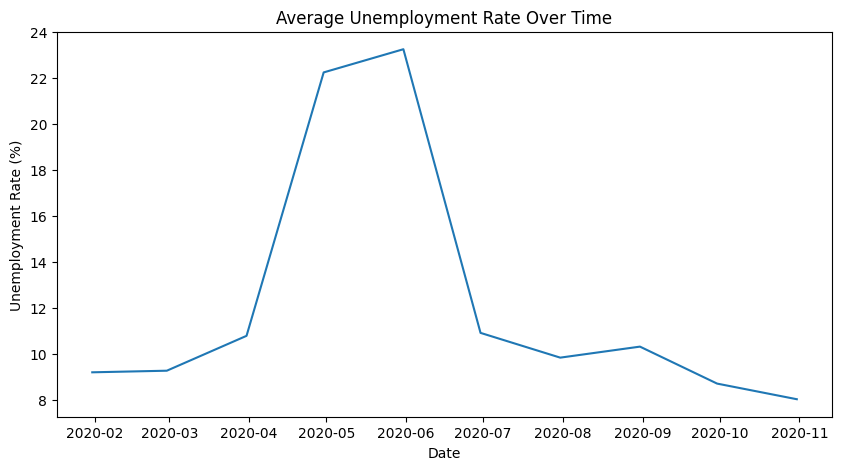

In [7]:
import matplotlib.pyplot as plt

df_avg = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(10,5))
plt.plot(df_avg.index, df_avg.values)

plt.title("Average Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.show()

The unemployment rate shows noticeable fluctuations over time. A significant increase is observed during mid-2020, followed by a gradual decline. This indicates changes in employment conditions over the observed period.

COVID-19 Impact analysis

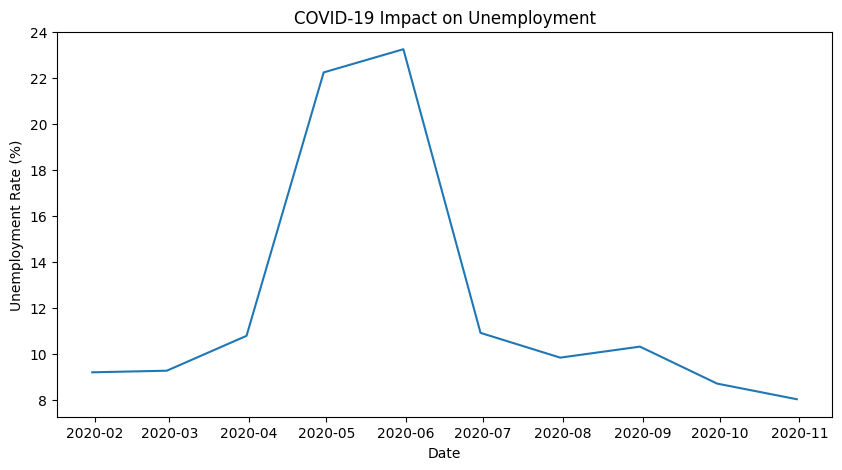

In [8]:
covid_data = df[df['Year'] >= 2019]

covid_avg = covid_data.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(10,5))
plt.plot(covid_avg.index, covid_avg.values)

plt.title("COVID-19 Impact on Unemployment")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.show()

A sharp increase in unemployment is observed during April–June 2020, with a peak around May–June. This period corresponds to the COVID-19 lockdown, where economic activities were heavily restricted. After this peak, the unemployment rate declines, indicating gradual economic recovery.

Seasonal Trends

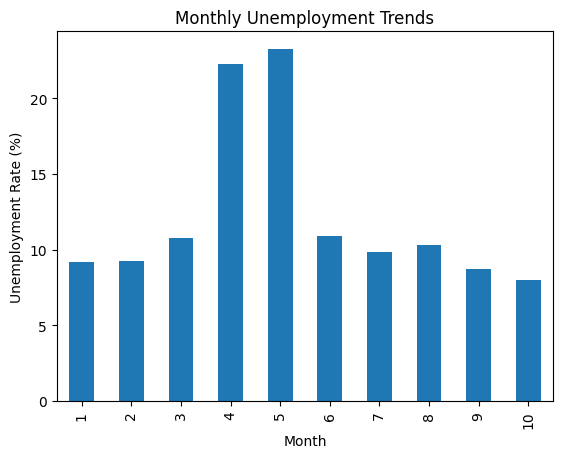

In [9]:
monthly_avg = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

import matplotlib.pyplot as plt

monthly_avg.plot(kind='bar')

plt.title("Monthly Unemployment Trends")
plt.xlabel("Month")
plt.ylabel("Unemployment Rate (%)")

plt.show()

The monthly analysis shows that unemployment rates are higher during April and May compared to other months. This indicates a seasonal pattern in unemployment during the year.

Conclusion

The analysis highlights the significant impact of COVID-19 on unemployment rates, particularly during the lockdown period. Seasonal patterns were also observed, with higher unemployment in specific months. Overall, the dataset provides valuable insights into how external factors influence employment trends.